# B.1 Variabelval och grundspecifikation — Poisson-GLM

Syftet med det här notebooken är att:

- definiera den optimala variabeluppsättningen för Poisson-GLM
- jämföra ekonomiska variabler (Omsättning vs Försäkringsbelopp) via AIC, BIC och out-of-sample-mått
- kontrollera multikollinearitet med VIF
- fastställa en grundspecifikation som används i efterföljande analys

**Valideringsstrategi:** Träna på 2021–2023, validera på 2024. Testdatan (2025) reserveras för slutlig utvärdering.

In [5]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor

sns.set_theme(style="whitegrid", context="notebook")

In [6]:
data_dir = Path("../../../data")
df = pd.read_csv(data_dir / "Entreprenadförsäkring training.csv")

# Temporal validation split
df_train = df[df["Ar"].isin([2021, 2022, 2023])].copy()
df_val = df[df["Ar"] == 2024].copy()

print(f"Träning (2021-2023): {df_train.shape[0]:,} rader, {int(df_train['AntalSkador'].sum()):,} skador")
print(f"Validering (2024):   {df_val.shape[0]:,} rader, {int(df_val['AntalSkador'].sum()):,} skador")
print(f"Träning exponering:  {df_train['Duration'].sum():,.0f} år")
print(f"Validering exponering: {df_val['Duration'].sum():,.0f} år")

Träning (2021-2023): 755,691 rader, 14,284 skador
Validering (2024):   277,695 rader, 5,446 skador
Träning exponering:  675,704 år
Validering exponering: 248,335 år


## 1. Feature Engineering

Log-transformering av ekonomiska variabler krävs eftersom de är kraftigt högerskevda (se A4). `log1p` används för att hantera nollvärden (även om inga förekommer i denna data). `Duration` log-transformeras separat för användning som offset i Poisson-GLM.

In [7]:
for dataset in [df_train, df_val]:
    dataset["log_Omsattning"] = np.log1p(dataset["Omsattning"])
    dataset["log_Forsakringsbelopp"] = np.log1p(dataset["Forsakringsbelopp"])
    dataset["log_Duration"] = np.log(dataset["Duration"])

print("Nya kolumner:", ["log_Omsattning", "log_Forsakringsbelopp", "log_Duration"])
print(f"log_Omsattning — min: {df_train['log_Omsattning'].min():.2f}, max: {df_train['log_Omsattning'].max():.2f}")
print(f"log_Forsakringsbelopp — min: {df_train['log_Forsakringsbelopp'].min():.2f}, max: {df_train['log_Forsakringsbelopp'].max():.2f}")
print(f"log_Duration — min: {df_train['log_Duration'].min():.4f}, max: {df_train['log_Duration'].max():.4f}")

Nya kolumner: ['log_Omsattning', 'log_Forsakringsbelopp', 'log_Duration']
log_Omsattning — min: 11.14, max: 20.92
log_Forsakringsbelopp — min: 10.82, max: 18.60
log_Duration — min: -2.3506, max: 0.0000


## 2. Hjälpfunktioner

Tre funktioner definieras:

- `fit_poisson_glm` — fittar en Poisson-GLM med log-länk och `log(Duration)` som offset
- `poisson_deviance` — beräknar mean Poisson deviance på ut-ur-stickprovsdata
- `evaluate_model` — samlar alla utvärderingsmått i en dict för enkel jämförelse

In [8]:
def fit_poisson_glm(formula: str, train_data: pd.DataFrame):
    """Fitta en Poisson-GLM med log-länk och Duration-offset."""
    model = smf.glm(
        formula=formula,
        data=train_data,
        family=sm.families.Poisson(link=sm.families.links.Log()),
        offset=train_data["log_Duration"],
    )
    return model.fit()


def poisson_deviance(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Beräkna mean Poisson deviance: 2 * mean(y*log(y/mu) - (y - mu)).

    Konvention: 0*log(0/mu) = 0, dvs. bidraget från y=0 är mu.
    """
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    with np.errstate(divide="ignore", invalid="ignore"):
        term = np.where(
            y_true > 0,
            y_true * np.log(y_true / y_pred) - (y_true - y_pred),
            y_pred,
        )
    return 2 * np.mean(term)


def evaluate_model(results, val_data: pd.DataFrame, label: str) -> dict:
    """Beräkna alla utvärderingsmått för en fittad modell."""
    y_val = val_data["AntalSkador"].values
    mu_val = results.predict(val_data, offset=val_data["log_Duration"]).values

    # BIC — använd deviance-baserad om tillgänglig, annars standard
    try:
        bic_val = results.bic_deviance
    except AttributeError:
        bic_val = results.bic

    return {
        "Modell": label,
        "Parametrar": int(results.df_model) + 1,
        "AIC": round(results.aic, 1),
        "BIC": round(bic_val, 1),
        "Log-likelihood": round(results.llf, 1),
        "Deviance (träning)": round(results.deviance, 1),
        "Deviance/df": round(results.deviance / results.df_resid, 4),
        "Val: Poisson deviance": round(poisson_deviance(y_val, mu_val), 6),
        "Val: MAE": round(np.mean(np.abs(y_val - mu_val)), 6),
        "Val: Pred. totalt": int(round(mu_val.sum())),
        "Val: Fakt. totalt": int(y_val.sum()),
        "Val: Pred/Akt": round(mu_val.sum() / y_val.sum(), 4),
    }


print("Hjälpfunktioner definierade.")

Hjälpfunktioner definierade.


## 3. Modellsekvens

Sju modeller med ökande komplexitet. Alla fittas på 2021–2023, utvärderas på 2024.

| Modell | Variabler | Syfte |
|--------|-----------|-------|
| M0 | Intercept | Null-baseline (portföljmedelvärde) |
| M1 | + Verksamhet | Starkaste kategoriska prediktorn |
| M2 | + GeografisktOmrade | Basmodell med båda kategoriska |
| M3 | + log(Omsättning) | **Primär kandidat** |
| M4 | + log(Försäkringsbelopp) istället | Alternativ storleksvariabel |
| M5 | + båda ekonomiska | Visa multikollinearitetsproblem |
| M6 | M3 + Självrisk (kat.) | Känslighetsanalys |

In [9]:
# M0: Null-modell (bara intercept)
m0 = fit_poisson_glm("AntalSkador ~ 1", df_train)
r0 = evaluate_model(m0, df_val, "M0: Null")
print(f"M0 fittad — AIC: {m0.aic:.1f}, Pred/Akt: {r0['Val: Pred/Akt']}")

M0 fittad — AIC: 141086.5, Pred/Akt: 0.9639


In [10]:
# M1: Verksamhet
m1 = fit_poisson_glm("AntalSkador ~ C(Verksamhet)", df_train)
r1 = evaluate_model(m1, df_val, "M1: Verksamhet")
print(f"M1 fittad — AIC: {m1.aic:.1f}, Pred/Akt: {r1['Val: Pred/Akt']}")

M1 fittad — AIC: 140468.3, Pred/Akt: 0.9641


In [11]:
# M2: Basmodell (Verksamhet + Geografi)
m2 = fit_poisson_glm("AntalSkador ~ C(Verksamhet) + C(GeografisktOmrade)", df_train)
r2 = evaluate_model(m2, df_val, "M2: Bas")
print(f"M2 fittad — AIC: {m2.aic:.1f}, Pred/Akt: {r2['Val: Pred/Akt']}")

M2 fittad — AIC: 139723.4, Pred/Akt: 0.9635


In [12]:
# M3: Bas + log(Omsättning) — primär kandidat
m3 = fit_poisson_glm(
    "AntalSkador ~ C(Verksamhet) + C(GeografisktOmrade) + log_Omsattning",
    df_train,
)
r3 = evaluate_model(m3, df_val, "M3: Bas + Omsättning")
print(f"M3 fittad — AIC: {m3.aic:.1f}, Pred/Akt: {r3['Val: Pred/Akt']}")

M3 fittad — AIC: 136971.0, Pred/Akt: 0.9641


In [13]:
# M4: Bas + log(Försäkringsbelopp) — alternativ storleksvariabel
m4 = fit_poisson_glm(
    "AntalSkador ~ C(Verksamhet) + C(GeografisktOmrade) + log_Forsakringsbelopp",
    df_train,
)
r4 = evaluate_model(m4, df_val, "M4: Bas + Förs.belopp")
print(f"M4 fittad — AIC: {m4.aic:.1f}, Pred/Akt: {r4['Val: Pred/Akt']}")

M4 fittad — AIC: 138304.6, Pred/Akt: 0.9645


In [14]:
# M5: Bas + båda ekonomiska variabler (multikollinearitetstest)
m5 = fit_poisson_glm(
    "AntalSkador ~ C(Verksamhet) + C(GeografisktOmrade) + log_Omsattning + log_Forsakringsbelopp",
    df_train,
)
r5 = evaluate_model(m5, df_val, "M5: Bas + Oms + Förs")
print(f"M5 fittad — AIC: {m5.aic:.1f}, Pred/Akt: {r5['Val: Pred/Akt']}")

M5 fittad — AIC: 136888.6, Pred/Akt: 0.9644


In [15]:
# M6: Känslighetsanalys — M3 + Självrisk som kategorisk
m6 = fit_poisson_glm(
    "AntalSkador ~ C(Verksamhet) + C(GeografisktOmrade) + log_Omsattning + C(Sjalvrisk)",
    df_train,
)
r6 = evaluate_model(m6, df_val, "M6: M3 + Självrisk")
print(f"M6 fittad — AIC: {m6.aic:.1f}, Pred/Akt: {r6['Val: Pred/Akt']}")

M6 fittad — AIC: 136257.1, Pred/Akt: 0.9637


## 4. Modelljämförelse

Sammanställning av alla sju modeller. Kolumnerna visar in-sample-mått (AIC, BIC, deviance) och out-of-sample-mått (Poisson deviance, MAE, predikterat/faktiskt totalantal på valideringsåret 2024).

In [16]:
comparison = pd.DataFrame([r0, r1, r2, r3, r4, r5, r6])
comparison = comparison.set_index("Modell")

# Visa med bästa värden markerade
display(comparison)

,Parametrar,AIC,BIC,Log-likelihood,Deviance (träning),Deviance/df,Val: Poisson deviance,Val: MAE,Val: Pred. totalt,Val: Fakt. totalt,Val: Pred/Akt
Modell,,,,,,,,,,,
M0: Null,1,141086.5,-10115788.4,-70542.2,112768.8,0.1492,0.153559,0.037743,5250,5446,0.9639
M1: Verksamhet,7,140468.3,-10116337.4,-70227.1,112138.6,0.1484,0.152649,0.037710,5250,5446,0.9641
M2: Bas,10,139723.4,-10117047.7,-69851.7,111387.7,0.1474,0.151624,0.037660,5247,5446,0.9635
M3: Bas + Omsättning,11,136971.0,-10119788.5,-68474.5,108633.3,0.1438,0.147653,0.037501,5250,5446,0.9641
M4: Bas + Förs.belopp,11,138304.6,-10118455.0,-69141.3,109966.9,0.1455,0.149594,0.037592,5253,5446,0.9645
M5: Bas + Oms + Förs,12,136888.6,-10119859.4,-68432.3,108548.9,0.1436,0.147541,0.037501,5252,5446,0.9644
M6: M3 + Självrisk,16,136257.1,-10120444.8,-68112.5,107909.4,0.1428,0.146526,0.037438,5248,5446,0.9637


### Tolkning av modelljämförelsen

Viktiga mönster att leta efter:

1. **M2 vs M0/M1:** Geografi tillför tydlig prediktiv information utöver verksamhet
2. **M3 vs M2:** Omsättning förbättrar modellen — lägre AIC och bättre valideringsdeviance
3. **M3 vs M4:** Omsättning bör ge bättre passning (starkare monotont samband, se A4)
4. **M5 vs M3:** Att lägga till Försäkringsbelopp ovanpå Omsättning ger marginell eller ingen förbättring, men ökar komplexiteten
5. **M6 vs M3:** Självrisk (kategorisk) tillför lite — svagt samband bekräftat i A4

Med n > 750 000 observationer är nästan alla variabler "statistiskt signifikanta" — det är *valideringsprestation* och *BIC* som avgör, inte p-värden.

## 5. Likelihood Ratio-test

Formella test för nästlade modellpar. Observera att med n > 750 000 har testerna extremt hög styrka — även triviala förbättringar blir signifikanta. AIC/BIC och valideringsmått väger därför tyngre för variabelval.

In [17]:
def lr_test(full_result, reduced_result, label: str) -> dict:
    """Likelihood ratio-test för nästlade modeller."""
    lr_stat = 2 * (full_result.llf - reduced_result.llf)
    df_diff = int(full_result.df_model - reduced_result.df_model)
    p_value = 1 - stats.chi2.cdf(lr_stat, df_diff)
    return {
        "Test": label,
        "LR-statistika": round(lr_stat, 2),
        "df": df_diff,
        "p-värde": f"{p_value:.2e}",
    }


lr_tests = pd.DataFrame([
    lr_test(m2, m0, "M2 vs M0: Kategoriska variabler"),
    lr_test(m3, m2, "M3 vs M2: + log(Omsättning)"),
    lr_test(m4, m2, "M4 vs M2: + log(Försäkringsbelopp)"),
    lr_test(m5, m3, "M5 vs M3: + log(Förs.belopp) ovanpå Oms"),
    lr_test(m6, m3, "M6 vs M3: + Självrisk"),
]).set_index("Test")

display(lr_tests)

,LR-statistika,df,p-värde
Test,,,
M2 vs M0: Kategoriska variabler,1381.10,9,0.00e+00
M3 vs M2: + log(Omsättning),2754.35,1,0.00e+00
M4 vs M2: + log(Försäkringsbelopp),1420.81,1,0.00e+00
M5 vs M3: + log(Förs.belopp) ovanpå Oms,84.42,1,0.00e+00
M6 vs M3: + Självrisk,723.98,5,0.00e+00


## 6. VIF-analys (Variance Inflation Factor)

VIF mäter hur mycket variansen i en koefficient ökar på grund av korrelation med andra variabler. Tumregel: VIF > 5 indikerar problematisk multikollinearitet, VIF > 10 allvarlig.

Vi jämför VIF för M3 (en ekonomisk variabel) och M5 (båda) för att visa hur korrelationen mellan Omsättning och Försäkringsbelopp (r = 0.574) påverkar stabiliteten.

*VIF beräknas på designmatrisen, inte på responsen. Subsampling till 100 000 rader för beräkningstid — VIF är en egenskap av X-matrisen, inte av y.*

In [18]:
import patsy


def compute_vif(formula_rhs: str, data: pd.DataFrame, sample_n: int = 100_000) -> pd.DataFrame:
    """Beräkna VIF från en patsy-designmatris. Subsamplar för prestanda."""
    if len(data) > sample_n:
        data_sample = data.sample(n=sample_n, random_state=42)
    else:
        data_sample = data

    _, X = patsy.dmatrices("AntalSkador ~ " + formula_rhs, data=data_sample, return_type="dataframe")

    vif_data = pd.DataFrame({
        "Variabel": X.columns,
        "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])],
    })
    return vif_data.sort_values("VIF", ascending=False).reset_index(drop=True)


print("=== M3: Bas + log(Omsättning) ===")
vif_m3 = compute_vif("C(Verksamhet) + C(GeografisktOmrade) + log_Omsattning", df_train)
display(vif_m3)

print("\n=== M5: Bas + log(Omsättning) + log(Försäkringsbelopp) ===")
vif_m5 = compute_vif(
    "C(Verksamhet) + C(GeografisktOmrade) + log_Omsattning + log_Forsakringsbelopp",
    df_train,
)
display(vif_m5)

=== M3: Bas + log(Omsättning) ===


,Variabel,VIF
0,Intercept,261.880356
1,C(GeografisktOmrade)[T.Storstad],3.005522
2,C(GeografisktOmrade)[T.Mellanstorstad],2.807465
3,C(GeografisktOmrade)[T.Småstad],2.405804
4,C(Verksamhet)[T.Övriga specialistföretag],1.179303
5,C(Verksamhet)[T.Målare],1.124818
6,C(Verksamhet)[T.Elektriker],1.123523
7,C(Verksamhet)[T.VVS],1.123443
8,C(Verksamhet)[T.Grävning & Schaktning],1.103543
9,C(Verksamhet)[T.Takarbeten],1.067297



=== M5: Bas + log(Omsättning) + log(Försäkringsbelopp) ===


,Variabel,VIF
0,Intercept,267.083913
1,C(GeografisktOmrade)[T.Storstad],3.005558
2,C(GeografisktOmrade)[T.Mellanstorstad],2.807473
3,C(GeografisktOmrade)[T.Småstad],2.405809
4,log_Omsattning,1.507272
5,log_Forsakringsbelopp,1.507200
6,C(Verksamhet)[T.Övriga specialistföretag],1.179353
7,C(Verksamhet)[T.Målare],1.124823
8,C(Verksamhet)[T.Elektriker],1.123526
9,C(Verksamhet)[T.VVS],1.123447


### VIF-tolkning

- **M3:** Alla VIF-värden bör vara låga (< 5), vilket indikerar att modellen inte lider av multikollinearitet.
- **M5:** VIF för `log_Omsattning` och `log_Forsakringsbelopp` bör vara förhöjda jämfört med M3, vilket bekräftar att de bär överlappande information om företagsstorlek.

Även om VIF kanske inte överstiger den klassiska gränsen 5–10 så motiverar den måttliga korrelationen (r = 0.574) tillsammans med den marginella prediktiva förbättringen att vi väljer *en* ekonomisk variabel snarare än båda.

## 7. Koefficienter och incidenskvoter (M3)

Rate ratio = exp(β). Tolkning: om rate ratio = 1.35 för en kategori innebär det 35 % högre skadefrekvens jämfört med referenskategorin, justerat för övriga variabler.

Referenskategorier (statsmodels default, alfabetisk ordning):
- Verksamhet: Byggföretag
- GeografisktOmråde: Landsbyggd

In [19]:
print(m3.summary())

print("\n" + "=" * 60)
print("Incidenskvoter (rate ratios) med 95 % konfidensintervall")
print("=" * 60)

rate_ratios = np.exp(m3.params)
ci = np.exp(m3.conf_int())
ci.columns = ["RR 2.5%", "RR 97.5%"]
rr_table = pd.DataFrame({"Rate Ratio": rate_ratios}).join(ci)
rr_table["Rate Ratio"] = rr_table["Rate Ratio"].round(4)
rr_table["RR 2.5%"] = rr_table["RR 2.5%"].round(4)
rr_table["RR 97.5%"] = rr_table["RR 97.5%"].round(4)

display(rr_table)

                 Generalized Linear Model Regression Results                  
Dep. Variable:            AntalSkador   No. Observations:               755691
Model:                            GLM   Df Residuals:                   755680
Model Family:                 Poisson   Df Model:                           10
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -68475.
Date:                Thu, 23 Apr 2026   Deviance:                   1.0863e+05
Time:                        10:55:15   Pearson chi2:                 7.43e+05
No. Iterations:                     7   Pseudo R-squ. (CS):           0.005457
Covariance Type:            nonrobust                                         
                                                coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------

,Rate Ratio,RR 2.5%,RR 97.5%
Intercept,0.0000,0.0000,0.0000
C(Verksamhet)[T.Elektriker],0.6898,0.6455,0.7372
C(Verksamhet)[T.Grävning & Schaktning],0.8570,0.8018,0.9159
C(Verksamhet)[T.Målare],0.6409,0.5986,0.6863
C(Verksamhet)[T.Takarbeten],1.1084,1.0301,1.1926
C(Verksamhet)[T.VVS],1.4272,1.3579,1.5000
C(Verksamhet)[T.Övriga specialistföretag],0.9809,0.9358,1.0281
C(GeografisktOmrade)[T.Mellanstorstad],1.2041,1.1294,1.2838
C(GeografisktOmrade)[T.Småstad],0.7567,0.7034,0.8141
C(GeografisktOmrade)[T.Storstad],1.4618,1.3748,1.5543


### Kort tolkning av koefficienter

Förväntade mönster baserat på deskriptiv analys:

- **VVS** bör ha högst rate ratio bland verksamheterna (ca 1.3–1.5 jmf med Byggföretag)
- **Storstad** bör ha högst rate ratio bland geografierna
- **log_Omsattning** bör ha positiv koefficient — högre omsättning associeras med fler skador per exponerat år

Djupare tolkning och affärsmässig diskussion görs i separat tolkningsnotebook (B.5 i planen).

## 8. Visualisering av valideringsprestation

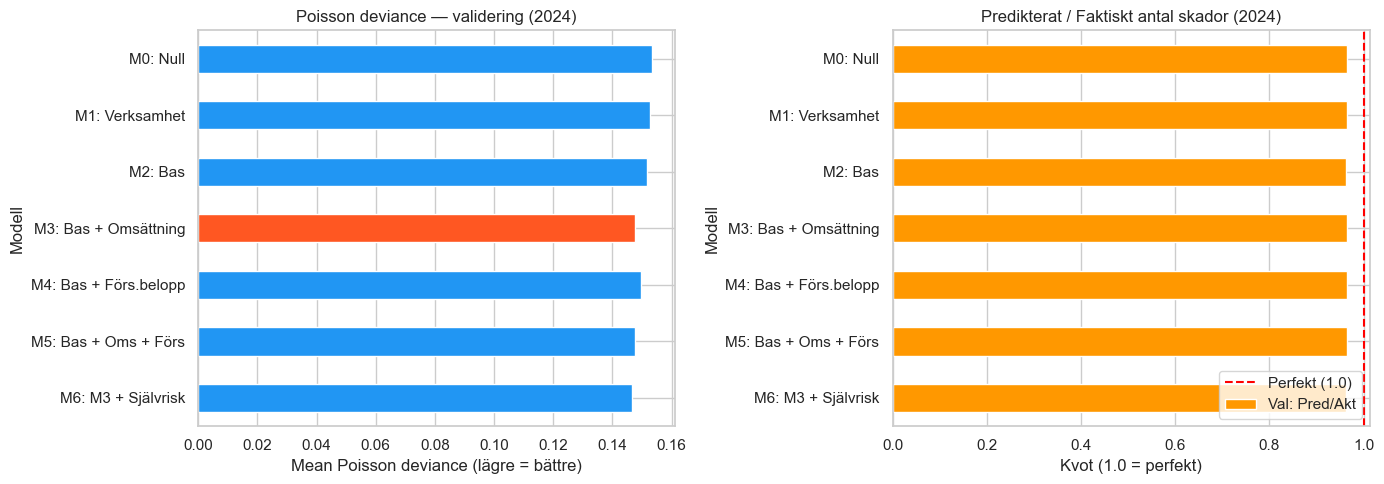

Figur sparad: B1-valideringsprestation.png


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Vänster: Poisson deviance på valideringsdata ---
deviance_data = comparison["Val: Poisson deviance"]
colors_dev = ["#2196F3" if idx != "M3: Bas + Omsättning" else "#FF5722" for idx in deviance_data.index]
deviance_data.plot.barh(ax=axes[0], color=colors_dev)
axes[0].set_title("Poisson deviance — validering (2024)", fontsize=12)
axes[0].set_xlabel("Mean Poisson deviance (lägre = bättre)")
axes[0].invert_yaxis()

# --- Höger: Predikterat / Faktiskt kvot ---
ratio_data = comparison["Val: Pred/Akt"]
colors_ratio = ["#4CAF50" if abs(v - 1) < 0.02 else "#FF9800" for v in ratio_data]
ratio_data.plot.barh(ax=axes[1], color=colors_ratio)
axes[1].axvline(x=1.0, color="red", linestyle="--", linewidth=1.5, label="Perfekt (1.0)")
axes[1].set_title("Predikterat / Faktiskt antal skador (2024)", fontsize=12)
axes[1].set_xlabel("Kvot (1.0 = perfekt)")
axes[1].legend(loc="lower right")
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig("B1-valideringsprestation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figur sparad: B1-valideringsprestation.png")

### Visuell tolkning

- **Vänster panel:** Poisson deviance sjunker stegvis från null-modellen (M0) till modeller med fler variabler. M3 bör vara bland de bästa — M5 och M6 ger marginella förbättringar trots ökad komplexitet.
- **Höger panel:** Kvoten predikterat/faktiskt antal skador bör ligga nära 1.0 för alla rimliga modeller. Avvikelse indikerar systematisk under- eller överprediktering av portföljen.

## 9. Slutsats och vald grundspecifikation

### Vald modell: M3

```
AntalSkador ~ C(Verksamhet) + C(GeografisktOmrade) + log_Omsattning + offset(log(Duration))
```

### Motivering

1. **Omsättning framför Försäkringsbelopp:** Starkare monotont samband med skadefrekvens (5.6× spridning vs 3.2× i decilanalysen, se A4). Bättre AIC/BIC. Tydligare affärstolkning — omsättning speglar projektvolym och exponering mot risk.

2. **Försäkringsbelopp exkluderat:** Korrelerat med Omsättning (r = 0.574 på log-skala). Att inkludera båda (M5) ger förhöjd VIF och marginell prediktiv förbättring som inte motiverar den ökade komplexiteten och instabiliteten.

3. **Självrisk exkluderad:** Svagt och inkonsekvent samband med skadefrekvens. Bara 6 unika värden. Känslighetsanalys (M6) bekräftar att bidraget är marginellt.

### Nästa steg

- **B2:** Testa årseffekt `C(Ar)` — förbättrar den prediktionen på 2024?
- **B3:** Modellkontroll (överdispersion, residualer, stabilitet)
- **B4:** Djupare tolkning av koefficienter och affärsmässig innebörd

In [21]:
FINAL_FORMULA = "AntalSkador ~ C(Verksamhet) + C(GeografisktOmrade) + log_Omsattning"

print("=" * 60)
print("VALD GRUNDSPECIFIKATION (B.1)")
print("=" * 60)
print(f"Formel:    {FINAL_FORMULA}")
print(f"Offset:    log(Duration)")
print(f"Familj:    Poisson (log-länk)")
print()
print("Valideringsresultat (2024):")
print(f"  AIC:              {m3.aic:.1f}")
print(f"  Poisson deviance: {r3['Val: Poisson deviance']:.6f}")
print(f"  MAE:              {r3['Val: MAE']:.6f}")
print(f"  Pred. totalt:     {r3['Val: Pred. totalt']:,}")
print(f"  Fakt. totalt:     {r3['Val: Fakt. totalt']:,}")
print(f"  Pred/Akt kvot:    {r3['Val: Pred/Akt']:.4f}")

VALD GRUNDSPECIFIKATION (B.1)
Formel:    AntalSkador ~ C(Verksamhet) + C(GeografisktOmrade) + log_Omsattning
Offset:    log(Duration)
Familj:    Poisson (log-länk)

Valideringsresultat (2024):
  AIC:              136971.0
  Poisson deviance: 0.147653
  MAE:              0.037501
  Pred. totalt:     5,250
  Fakt. totalt:     5,446
  Pred/Akt kvot:    0.9641
